In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import yaml
from pathlib import Path
import shutil

# ====================================
# CONFIGURACIÓN
# ====================================
YOLO_DATASET = "/content/drive/MyDrive/dataset"
OUTPUT_DIR = "/content/drive/MyDrive/llava_dataset"

SPLITS = ["train", "valid", "test"]

# ====================================
# FUNCIONES
# ====================================

def load_classes(data_yaml_path):
    with open(data_yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    names = data["names"]

    if isinstance(names, dict):
        return names

    return {i: name for i, name in enumerate(names)}


def yolo_to_center(label_line):
    parts = label_line.strip().split()

    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    width = float(parts[3])
    height = float(parts[4])

    return class_id, x_center, y_center, width, height


def position_text(x, y):

    horizontal = "centro"
    vertical = "centro"

    if x < 0.33:
        horizontal = "izquierda"
    elif x > 0.66:
        horizontal = "derecha"

    if y < 0.33:
        vertical = "parte superior"
    elif y > 0.66:
        vertical = "parte inferior"

    if horizontal == "centro" and vertical == "centro":
        return "en el centro de la imagen"

    return f"en la {vertical}, hacia la {horizontal}"


def build_description(objects):

    if not objects:
        return "No se observan objetos relevantes."

    text = "En la escena cenital se observan: "

    descriptions = []

    for obj in objects:
        descriptions.append(
            f"{obj['name']} ubicado {position_text(obj['x'], obj['y'])}"
        )

    return text + "; ".join(descriptions) + "."


def build_qa(objects):

    classes = sorted(set(obj["name"] for obj in objects))

    description = build_description(objects)

    elements = (
        "Los elementos detectados son: " + ", ".join(classes) + "."
        if classes else
        "No se detectan elementos."
    )

    qa = [
        {
            "from": "human",
            "value": "<image>\nDescribe la escena cenital."
        },
        {
            "from": "gpt",
            "value": description
        },
        {
            "from": "human",
            "value": "¿Qué objetos aparecen en la imagen?"
        },
        {
            "from": "gpt",
            "value": elements
        }
    ]

    return qa


# ====================================
# PROCESO PRINCIPAL
# ====================================

yolo_path = Path(YOLO_DATASET)
output_path = Path(OUTPUT_DIR)

images_output = output_path / "images"

output_path.mkdir(exist_ok=True)
images_output.mkdir(exist_ok=True)

data_yaml = yolo_path / "data.yaml"

class_names = load_classes(data_yaml)

llava_data = []

for split in SPLITS:

    images_dir = yolo_path / split / "images"
    labels_dir = yolo_path / split / "labels"

    if not images_dir.exists():
        continue

    for image_file in images_dir.iterdir():

        if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        label_file = labels_dir / f"{image_file.stem}.txt"

        objects = []

        if label_file.exists():

            with open(label_file, "r", encoding="utf-8") as f:
                lines = f.readlines()

            for line in lines:

                if not line.strip():
                    continue

                class_id, x, y, w, h = yolo_to_center(line)

                class_name = class_names.get(
                    class_id,
                    f"clase_{class_id}"
                )

                objects.append({
                    "name": class_name,
                    "x": x,
                    "y": y,
                    "w": w,
                    "h": h
                })

        new_image_name = f"{split}_{image_file.name}"

        shutil.copy(
            image_file,
            images_output / new_image_name
        )

        item = {
            "id": image_file.stem,
            "image": f"images/{new_image_name}",
            "conversations": build_qa(objects)
        }

        llava_data.append(item)

# ====================================
# GUARDAR JSON
# ====================================

output_json = output_path / "train.json"

with open(output_json, "w", encoding="utf-8") as f:
    json.dump(
        llava_data,
        f,
        ensure_ascii=False,
        indent=2
    )

print("================================")
print("Conversión completada")
print(f"Total muestras: {len(llava_data)}")
print(f"JSON generado en:")
print(output_json)
print("================================")

Conversión completada
Total muestras: 2563
JSON generado en:
/content/drive/MyDrive/llava_dataset/train.json


In [ ]:
!nvidia-smi

Fri May 29 06:02:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%cd /content
!git clone https://github.com/haotian-liu/LLaVA.git
%cd /content/LLaVA

/content
Cloning into 'LLaVA'...
remote: Enumerating objects: 2297, done.
remote: Total 2297 (delta 0), reused 0 (delta 0), pack-reused 2297 (from 1)
Receiving objects: 100% (2297/2297), 13.71 MiB | 31.34 MiB/s, done.
Resolving deltas: 100% (1404/1404), done.
/content/LLaVA


In [ ]:
!pip install -e . --no-deps

Obtaining file:///content/LLaVA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llava (pyproject.toml) ... done
  Created wheel for llava: filename=llava-1.2.2.post1-0.editable-py3-none-any.whl size=17888 sha256=444a20d12165a072e42b0779f39415618b486538f4204503d1659856c46f9407
  Stored in directory: /tmp/pip-ephem-wheel-cache-ssdgtdji/wheels/e5/0e/a5/e0f37963befcb0a4cf2bd7abeef83f743ef7d9ba56df1b852e
Successfully built llava


In [ ]:
!pip install transformers==4.37.2 tokenizers==0.15.2
!pip install bitsandbytes peft accelerate
!pip install sentencepiece shortuuid einops einops-exts timm markdown2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fo

In [ ]:
import torch
import transformers
import bitsandbytes
import peft

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("bitsandbytes OK")

ImportError: cannot import name 'MODEL_TYPE_TO_PEFT_MODEL_MAPPING' from 'peft.mapping' (/usr/local/lib/python3.12/dist-packages/peft/mapping.py)

In [ ]:
!pip uninstall -y peft
!pip install peft==0.7.1

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llava 1.2.2.post1 requires accelerate==0.21.0, but you have accelerate 1.13.0 which is incompatible.
llava 1.2.2.post1 requires einops==0.6.1, but you have einops 0.8.2 which is incompatible.
llava 1.2.2.post1 requires gradio==4.16.0, but you have gradio 5.50.0 which is incompatible.
llava 1.2.2.post1 requires gradio_client==0.8.1, but you have gradio-client 1.14.0 which is incompatible.
llava 1.2.2.post1 requires httpx==0.24.0, but you have httpx 0.28.1 which is incompatible.
llava 1.2.2.post1 requires scikit-learn==1.2.2, but you have scikit-learn 1.6.1 which is incompatible.
llava 1.2.2.post1 requires sentencepiece==0.1.99, but 

In [ ]:
!pip uninstall -y peft
!pip uninstall -y peft
!pip install --no-cache-dir --force-reinstall peft==0.7.1

Found existing installation: peft 0.7.1
Uninstalling peft-0.7.1:
  Successfully uninstalled peft-0.7.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 34.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 256.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 202.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 302.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 322.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 410.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 400.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 66.6 MB/s eta 0:00:00
   ━━━━

In [ ]:
import torch
import transformers
import peft

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

ModuleNotFoundError: Could not import module 'PreTrainedModel'. Are this object's requirements defined correctly?

In [ ]:
!pip uninstall -y torchvision
!pip install --no-cache-dir --force-reinstall torchvision

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 222.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 247.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 198.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 137.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 144.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 145.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 149.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 165.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1

In [ ]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.12.0+cu130
Torchvision: 0.27.0+cu130
CUDA: True


In [ ]:
import transformers
import peft

print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

Transformers: 5.9.0
PEFT: 0.7.1


In [ ]:
from llava.model import *
print("LLaVA importado correctamente")

LLaVA importado correctamente


In [ ]:
import json
from pathlib import Path

DATA_PATH = "/content/drive/MyDrive/llava_dataset/train.json"
IMAGE_FOLDER = "/content/drive/MyDrive/llava_dataset/images"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Cantidad de muestras:", len(data))
print(data[0])

img_path = Path(IMAGE_FOLDER) / Path(data[0]["image"]).name
print("Imagen encontrada:", img_path.exists())
print("Ruta imagen:", img_path)

Cantidad de muestras: 2563
{'id': '127_jpeg.rf.a0ee80cbe23d2e86df07252de2a5ed0e', 'image': 'images/train_127_jpeg.rf.a0ee80cbe23d2e86df07252de2a5ed0e.jpg', 'conversations': [{'from': 'human', 'value': '<image>\nDescribe la escena cenital.'}, {'from': 'gpt', 'value': 'No se observan objetos relevantes.'}, {'from': 'human', 'value': '¿Qué objetos aparecen en la imagen?'}, {'from': 'gpt', 'value': 'No se detectan elementos.'}]}
Imagen encontrada: True
Ruta imagen: /content/drive/MyDrive/llava_dataset/images/train_127_jpeg.rf.a0ee80cbe23d2e86df07252de2a5ed0e.jpg


In [ ]:
DATA_PATH = "/content/drive/MyDrive/llava_dataset/train.json"
IMAGE_FOLDER = "/content/drive/MyDrive/llava_dataset/images"
OUTPUT_DIR = "/content/drive/MyDrive/llava_checkpoints/llava_lora_robot"

!python -m llava.train.train_mem \
    --lora_enable True \
    --lora_r 64 \
    --lora_alpha 16 \
    --mm_projector_lr 2e-5 \
    --model_name_or_path liuhaotian/llava-v1.5-7b \
    --version v1 \
    --data_path "$DATA_PATH" \
    --image_folder "$IMAGE_FOLDER" \
    --vision_tower openai/clip-vit-large-patch14-336 \
    --mm_projector_type mlp2x_gelu \
    --mm_vision_select_layer -2 \
    --mm_use_im_start_end False \
    --mm_use_im_patch_token False \
    --bf16 False \
    --fp16 True \
    --output_dir "$OUTPUT_DIR" \
    --num_train_epochs 1 \
    --per_device_train_batch_size 1 \
    --gradient_accumulation_steps 4 \
    --evaluation_strategy "no" \
    --save_strategy "steps" \
    --save_steps 200 \
    --save_total_limit 1 \
    --learning_rate 2e-4 \
    --weight_decay 0. \
    --warmup_ratio 0.03 \
    --lr_scheduler_type "cosine" \
    --logging_steps 1 \
    --tf32 True \
    --model_max_length 2048 \
    --gradient_checkpointing True \
    --lazy_preprocess True \
    --report_to none

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
config.json: 1.16kB [00:00, 5.78MB/s]
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
pytorch_model.bin.index.json: 27.1kB [00:00, 87.9MB/s]
pytorch_model-00001-of-00002.bin:   0% 0.00/9.98G [00:00<?, ?B/s]
pytorch_model-00001-of-00002.bin:   1% 134M/9.98G [00:01<01:33, 106MB/s]
pytorch_model-00001-of-00002.bin:   3% 268M/9.98G [00:02<01:09, 139MB/s]
pytorch_model-00001-of-00002.bin:   7% 670M/9.98G [00:03<00:39, 234MB/s]
pytorch_model-00001-of-00002.bin:   9% 939M/9.98G [00:03<00:26, 343MB/s]
pytorch_model-00001-of-00002.bin:  12% 1.21G/9.98G [00:03<00:19, 457MB/s]
pytorch_model-00001-of-00002.bin:  

In [ ]:
!pip uninstall -y transformers tokenizers
!pip install --no-cache-dir --force-reinstall transformers==4.37.2 tokenizers==0.15.2


Found existing installation: transformers 5.9.0
Uninstalling transformers-5.9.0:
  Successfully uninstalled transformers-5.9.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 231.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 292.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 276.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 269.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 409.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 216.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 333.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import transformers
print(transformers.__version__)


4.37.2


In [ ]:
from llava.model import *
print("LLaVA importado correctamente")

LLaVA importado correctamente


In [ ]:
DATA_PATH = "/content/drive/MyDrive/llava_dataset/train.json"
IMAGE_FOLDER = "/content/drive/MyDrive/llava_dataset/images"
OUTPUT_DIR = "/content/drive/MyDrive/llava_checkpoints/llava_lora_robot"

!python -m llava.train.train \
    --lora_enable True \
    --lora_r 64 \
    --lora_alpha 16 \
    --mm_projector_lr 2e-5 \
    --model_name_or_path liuhaotian/llava-v1.5-7b \
    --version v1 \
    --data_path "$DATA_PATH" \
    --image_folder "$IMAGE_FOLDER" \
    --vision_tower openai/clip-vit-large-patch14-336 \
    --mm_projector_type mlp2x_gelu \
    --mm_vision_select_layer -2 \
    --mm_use_im_start_end False \
    --mm_use_im_patch_token False \
    --bf16 False \
    --fp16 True \
    --output_dir "$OUTPUT_DIR" \
    --num_train_epochs 1 \
    --per_device_train_batch_size 1 \
    --gradient_accumulation_steps 4 \
    --evaluation_strategy "no" \
    --save_strategy "steps" \
    --save_steps 200 \
    --save_total_limit 1 \
    --learning_rate 2e-4 \
    --weight_decay 0. \
    --warmup_ratio 0.03 \
    --lr_scheduler_type "cosine" \
    --logging_steps 1 \
    --tf32 True \
    --model_max_length 2048 \
    --gradient_checkpointing True \
    --lazy_preprocess True \
    --report_to none

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
config.json: 4.76kB [00:00, 17.8MB/s]
Loading checkpoint shards: 100% 2/2 [00:03<00:00,  1.99s/it]
generation_config.json: 100% 124/124 [00:00<00:00, 1.01MB/s]
Adding LoRA adapters...
bitsandbytes library load error: libnvJitLink.so.13: cannot open shared object file: No such file or directory
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextensi

In [ ]:
!pip install nvidia-nvjitlink-cu13


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for nvidia-nvjitlink-cu13 (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for nvidia-nvjitlink-cu13
Failed to build nvidia-nvjitlink-cu13
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (nvidia-nvjitlink-cu13)


In [ ]:
!pip uninstall -y bitsandbytes
!pip install --no-cache-dir bitsandbytes==0.43.3

Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 78.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llava 1.2.2.post1 requires accelerate==0.21.0, but you have accelerate 1.13.0 which is incompatible.
llava 1.2.2.post1 requires einops==0.6.1, but you have einops 0.8.2 which is incompatible.
llava 1.2.2.post1 requires gradio==4.16.0, but you have gradio 5.50.0 which is incompatible.
llava 1.2.2.post1 requires gradio_client==0.8.1, but you have gradio-client 1.14.0 which is incompatible.
llava 1.2.2.post1 requires httpx==0.24.0, but you have httpx 0.28.1 which is incompatible.
llava 1.2.2.post1 requires scikit-learn==1.2.2, but you have scikit-learn 1.6.1 which is incompatible.
llava 1.2.2.post1 requires se

In [ ]:
import bitsandbytes
print("bitsandbytes OK")

In [ ]:
!nvidia-smi

Fri Jun  5 13:26:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   49C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content
!ls

/content
drive  sample_data


In [ ]:
!git clone https://github.com/haotian-liu/LLaVA.git
%cd /content/LLaVA

Cloning into 'LLaVA'...
remote: Enumerating objects: 2297, done.
remote: Total 2297 (delta 0), reused 0 (delta 0), pack-reused 2297 (from 1)
Receiving objects: 100% (2297/2297), 13.71 MiB | 24.72 MiB/s, done.
Resolving deltas: 100% (1404/1404), done.
/content/LLaVA


In [ ]:
%cd /content/LLaVA

/content/LLaVA


In [ ]:
!nvidia-smi
!python --version

Thu Jun  4 13:47:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%cd /content
!git clone https://github.com/haotian-liu/LLaVA.git
%cd /content/LLaVA

/content
fatal: destination path 'LLaVA' already exists and is not an empty directory.
/content/LLaVA


In [ ]:
!pip install -e . --no-deps
!pip install transformers==4.37.2 tokenizers==0.15.2
!pip install peft==0.7.1 accelerate==0.21.0
!pip install sentencepiece shortuuid einops==0.6.1 einops-exts==0.0.4 timm==0.6.13 markdown2

Obtaining file:///content/LLaVA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llava (pyproject.toml) ... done
  Created wheel for llava: filename=llava-1.2.2.post1-0.editable-py3-none-any.whl size=17892 sha256=2af4c75babd1b1346e51a36e9ab1ae1613c6418a44f82542cb65313399069e77
  Stored in directory: /tmp/pip-ephem-wheel-cache-rka5sevb/wheels/e5/0e/a5/e0f37963befcb0a4cf2bd7abeef83f743ef7d9ba56df1b852e
Successfully built llava
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation

In [ ]:
import torch
import transformers
import peft

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

Torch: 2.11.0+cu128
CUDA: True
Transformers: 4.37.2
PEFT: 0.7.1


In [ ]:
from llava.model import *
print("LLaVA importado correctamente")

LLaVA importado correctamente


In [ ]:
import json

DATA_PATH = "/content/drive/MyDrive/llava_dataset/train.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Muestras:", len(data))
print(data[0])

Muestras: 2563
{'id': '127_jpeg.rf.a0ee80cbe23d2e86df07252de2a5ed0e', 'image': 'images/train_127_jpeg.rf.a0ee80cbe23d2e86df07252de2a5ed0e.jpg', 'conversations': [{'from': 'human', 'value': '<image>\nDescribe la escena cenital.'}, {'from': 'gpt', 'value': 'No se observan objetos relevantes.'}, {'from': 'human', 'value': '¿Qué objetos aparecen en la imagen?'}, {'from': 'gpt', 'value': 'No se detectan elementos.'}]}


In [ ]:
!pip install deepspeed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.7 MB/s eta 0:00:00
  Created wheel for deepspeed: filename=deepspeed-0.19.1-py3-none-any.whl size=1851782 sha256=f13383b2b9678449bb68762ffba26720e8413fa899f7a3002d3c59428e9702d0
  Stored in directory: /root/.cache/pip/wheels/ac/26/a4/6e4a074ecb7413ef47607c20bef4bcb2180a10330e5e844f92
Successfully built deepspeed


In [ ]:
DATA_PATH = "/content/drive/MyDrive/llava_dataset/train.json"
IMAGE_FOLDER = "/content/drive/MyDrive/llava_dataset"
OUTPUT_DIR = "/content/drive/MyDrive/llava_checkpoints/llava_lora_robot_test"

!python -m llava.train.train \
    --lora_enable True \
    --lora_r 64 \
    --lora_alpha 16 \
    --mm_projector_lr 2e-5 \
    --model_name_or_path liuhaotian/llava-v1.5-7b \
    --version v1 \
    --data_path "$DATA_PATH" \
    --image_folder "$IMAGE_FOLDER" \
    --vision_tower openai/clip-vit-large-patch14-336 \
    --mm_projector_type mlp2x_gelu \
    --mm_vision_select_layer -2 \
    --mm_use_im_start_end False \
    --mm_use_im_patch_token False \
    --bf16 True \
    --fp16 False \
    --output_dir "$OUTPUT_DIR" \
    --num_train_epochs 1 \
    --per_device_train_batch_size 1 \
    --gradient_accumulation_steps 4 \
    --evaluation_strategy "no" \
    --save_strategy "steps" \
    --save_steps 200 \
    --save_total_limit 1 \
    --learning_rate 2e-4 \
    --weight_decay 0. \
    --warmup_ratio 0.03 \
    --lr_scheduler_type "cosine" \
    --logging_steps 1 \
    --tf32 True \
    --model_max_length 2048 \
    --gradient_checkpointing True \
    --lazy_preprocess True \
    --report_to none

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
config.json: 1.16kB [00:00, 5.05MB/s]
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
pytorch_model.bin.index.json: 27.1kB [00:00, 95.8MB/s]
pytorch_model-00001-of-00002.bin:   0% 0.00/9.98G [00:00<?, ?B/s]
pytorch_model-00001-of-00002.bin:   1% 67.0M/9.98G [00:01<03:09, 52.4MB/s]
pytorch_model-00001-of-00002.bin:   1% 134M/9.98G [00:02<02:22, 69.3MB/s] 
pytorch_model-00001-of-00002.bin:   4% 402M/9.98G [00:02<00:38, 248MB/s] 
pytorch_model-00001-of-00002.bin:   6% 603M/9.98G [00:02<00:31, 300MB/s]
pytorch_model-00001-of-00002.bin:  12% 1.21G/9.98G [00:04<00:24, 361MB/s]
pytorch_model-00001-of-00002.b

In [ ]:
!ls -lh /content/drive/MyDrive/llava_checkpoints/llava_lora_robot_test

total 346M
-rw------- 1 root root  654 Jun  4 14:18 adapter_config.json
-rw------- 1 root root 306M Jun  4 14:18 adapter_model.safetensors
drwx------ 2 root root 4.0K Jun  4 14:16 checkpoint-600
-rw------- 1 root root 1.4K Jun  4 14:18 config.json
-rw------- 1 root root  41M Jun  4 14:18 non_lora_trainables.bin
-rw------- 1 root root 5.0K Jun  4 14:18 README.md
-rw------- 1 root root  76K Jun  4 14:18 trainer_state.json


In [ ]:
%cd /content
!git clone https://github.com/haotian-liu/LLaVA.git
%cd /content/LLaVA

/content
Cloning into 'LLaVA'...
remote: Enumerating objects: 2297, done.
remote: Total 2297 (delta 0), reused 0 (delta 0), pack-reused 2297 (from 1)
Receiving objects: 100% (2297/2297), 13.71 MiB | 17.23 MiB/s, done.
Resolving deltas: 100% (1405/1405), done.
/content/LLaVA


In [ ]:
!pip install -e . --no-deps
!pip install transformers==4.37.2 tokenizers==0.15.2
!pip install peft==0.7.1 accelerate==0.21.0
!pip install sentencepiece shortuuid einops==0.6.1 einops-exts==0.0.4 timm==0.6.13 markdown2

Obtaining file:///content/LLaVA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llava (pyproject.toml) ... done
  Created wheel for llava: filename=llava-1.2.2.post1-0.editable-py3-none-any.whl size=17890 sha256=320d2fa577f71fa5c5747572b0b6ef345f02fe45624078b9cf4a4608afc008b9
  Stored in directory: /tmp/pip-ephem-wheel-cache-110t_rzn/wheels/e5/0e/a5/e0f37963befcb0a4cf2bd7abeef83f743ef7d9ba56df1b852e
Successfully built llava
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 157.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installatio

In [ ]:
from llava.model import *
print("LLaVA OK")

LLaVA OK


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

/content/LLaVA


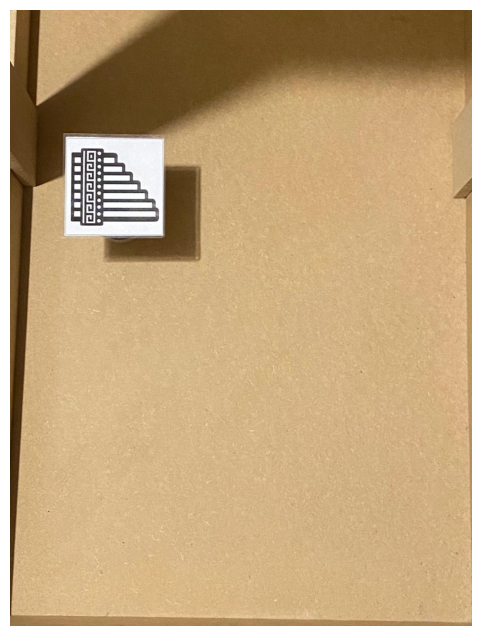

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading LLaVA from base model...
Loading checkpoint shards: 100% 2/2 [00:04<00:00,  2.15s/it]
Loading additional LLaVA weights...
Loading LoRA weights...
Merging LoRA weights...
Model is loaded...
En la escena cenital se observan: zampona ubicado en la parte superior, hacia la izquierda.


In [ ]:
%cd /content/LLaVA

MODEL_BASE = "liuhaotian/llava-v1.5-7b"
MODEL_PATH = "/content/drive/MyDrive/llava_checkpoints/llava_lora_robot_test"
IMAGE_FILE = "/content/drive/MyDrive/pruebas LLAvA/006.jpeg"

img = Image.open(IMAGE_FILE)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

!python -m llava.eval.run_llava \
    --model-path "$MODEL_PATH" \
    --model-base "$MODEL_BASE" \
    --image-file "$IMAGE_FILE" \
    --query "Describe la escena cenital."